# RQ1 — Visual assessment of thermal comfort across cities and social groups

The first research question asks how thermal comfort is perceived at the city scale and whether that perception differs systematically across respondent profiles. It builds on the survey data prepared in `preprocessing.ipynb`: only questionnaire fields that survive city-specific variation screening (§1.2) and collinearity review (§2.2) enter the profile analyses below. Inter-rater agreement and city-level summaries use all respondents; respondent-profile sections apply a-priori category rules and exclude non-binary gender respondents.

The notebook proceeds in three steps: (1) inter-rater agreement, (2) city-level perception profiles, and (3) comfort ratings across respondent profiles—with an overview figure, a-priori category merges, and per-variable comparison tables (§3.1–§3.16) for Detmold and Turin. Each step is introduced below, followed by the corresponding tables and figures, and a results and discussion section.


In [1]:
import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

import config as cfg
from config import (
    CITIES,
    CITY_COLORS,
    FIGURES_DIR,
    TABLES_DIR,
)
from utils import (
    apply_plot_theme,
    apply_rq1_profile_sample,
    category_mean_ratings_table,
    city_level_comfort_stats,
    comfort_numeric,
    inter_rater_spearman_summary,
    inter_rater_spearman_city_summary,
    inter_rater_image_agreement_summary,
    load_cleaned_data,
    ordered_questionnaire_profile_columns,
    plot_category_mean_ratings_grid,
    plot_city_level_distributions,
    plot_inter_rater_spearman_distribution,
    questionnaire_model_columns_by_city,
    rq1_category_mean_ratings_table,
    rq1_variable_category_tables,
    variable_category_comparison_table,
    save_figure,
    save_table,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

apply_plot_theme()
df_survey = comfort_numeric(load_cleaned_data())
df_rq1_profile = apply_rq1_profile_sample(df_survey)
questionnaire_cols_by_city = questionnaire_model_columns_by_city(df_rq1_profile)
rq1_profile_variables = ordered_questionnaire_profile_columns(questionnaire_cols_by_city)

print(f"Respondents (all): {len(df_survey)}")
print(f"Respondents (RQ1 profiles, non-binary gender excluded): {len(df_rq1_profile)}")
print("Questionnaire fields for RQ1 (after preprocessing):")
for city in CITIES:
    labels = [cfg.QUESTIONNAIRE_VARIABLE_LABELS.get(c, c) for c in questionnaire_cols_by_city[city]]
    print(f"  {city} ({len(labels)}): {', '.join(labels)}")


Respondents (all): 235
Respondents (RQ1 profiles, non-binary gender excluded): 234
Questionnaire fields for RQ1 (after preprocessing):
  Detmold (15): Age, Birthplace, City relationship, Daily activity, Education, Gender, Heat adaptation, Modify routes for heat, Occupation, Summer description, Time in city, Transport (car), Transport (cycling), Transport (public), Transport (walking)
  Turin (15): Age, Birthplace, City relationship, Daily activity, Education, Gender, Heat adaptation, Modify routes for heat, Occupation, Summer description, Time in city, Transport (car), Transport (cycling), Transport (public), Transport (walking)


## 1. Inter-rater agreement

Because each respondent rated the same set of streetscape images, it must first be established whether comfort judgments reflect a shared perceptual ordering or arbitrary use of the ordinal scale. Aggregating ratings into city-level profiles is justified only if respondents tend to rank the same scenes as more or less comfortable, as argued in comparable photo-based thermal perception research (Urban et al., 2022).

Comfort was collected on a five-point ordinal scale. For such data, Spearman's rank correlation is appropriate: it measures whether two respondents preserve the same relative ordering of scenes without requiring identical absolute scores (Spearman, 1904). Pairs in which one respondent assigned the same rating to every image are excluded, because zero within-person variation cannot be correlated meaningfully with any other response pattern (Urban et al., 2022). Rank-based association measures have likewise been used when relating morphometric and environmental variables to comfort outcomes in recent local-climate-zone and street-canyon work (Liu et al., 2026).

Two agreement checks are reported below.

**City-level (profile).** For each city separately, pairwise Spearman ρ is computed among respondents who completed all ten image ratings. Each correlation compares two respondents' full ten-image comfort profiles. A summary table reports the number of pairs and the central tendency and spread of ρ.

**Image-level.** For each city and each image separately, respondents contribute one ordinal rating. Profile-level Spearman ρ is not defined in that setting, so pairwise ordinal agreement is used instead: for each respondent pair, agreement is scored as `1 − |a − b| / 4` on the 1–5 scale (1 = identical ratings, 0 = maximum disagreement). The same summary statistics are reported per image.

A companion figure shows the full city-level distribution of pairwise profile correlations. Together, these outputs indicate whether within-city ratings can be treated as comparable when describing city-scale comfort profiles in the first research question.


In [2]:
# City-level: pairwise Spearman ρ across 10-image profiles
df_inter_rater_city = inter_rater_spearman_city_summary(df_survey)
save_table("rq1_inter_rater_spearman_city", df_inter_rater_city)
display(df_inter_rater_city)

# Image-level: pairwise ordinal agreement per streetscape image
df_inter_rater_image = inter_rater_image_agreement_summary(df_survey)
save_table("rq1_inter_rater_agreement_image", df_inter_rater_image)
display(df_inter_rater_image)


,city,n_pairs,mean,std,min,p25,median,p75,max
0,Detmold,6441,0.460,0.316,-0.859,0.285,0.520,0.702,1.0
1,Turin,6903,0.409,0.345,-0.906,0.194,0.471,0.675,1.0


,city,image,n_raters,n_pairs,mean,std,min,p25,median,p75,max,mean_rating,std_rating
0,Detmold,point_1,116,6670,0.751,0.223,0.00,0.75,0.75,1.0,1.0,2.267,0.945
1,Detmold,point_2,116,6670,0.764,0.202,0.00,0.75,0.75,1.0,1.0,3.362,0.879
2,Detmold,point_3,116,6670,0.738,0.227,0.00,0.50,0.75,1.0,1.0,2.043,0.982
3,Detmold,point_4,116,6670,0.802,0.183,0.25,0.75,0.75,1.0,1.0,4.026,0.763
4,Detmold,point_5,116,6670,0.773,0.209,0.00,0.75,0.75,1.0,1.0,2.931,0.872
5,Detmold,point_6,116,6670,0.771,0.200,0.00,0.75,0.75,1.0,1.0,2.759,0.861
6,Detmold,point_7,116,6670,0.729,0.222,0.00,0.50,0.75,1.0,1.0,2.974,0.991
7,Detmold,point_8,116,6670,0.749,0.223,0.00,0.50,0.75,1.0,1.0,2.397,0.950
8,Detmold,point_9,116,6670,0.812,0.200,0.00,0.75,0.75,1.0,1.0,3.759,0.776
9,Detmold,point_10,116,6670,0.770,0.198,0.00,0.75,0.75,1.0,1.0,3.483,0.860


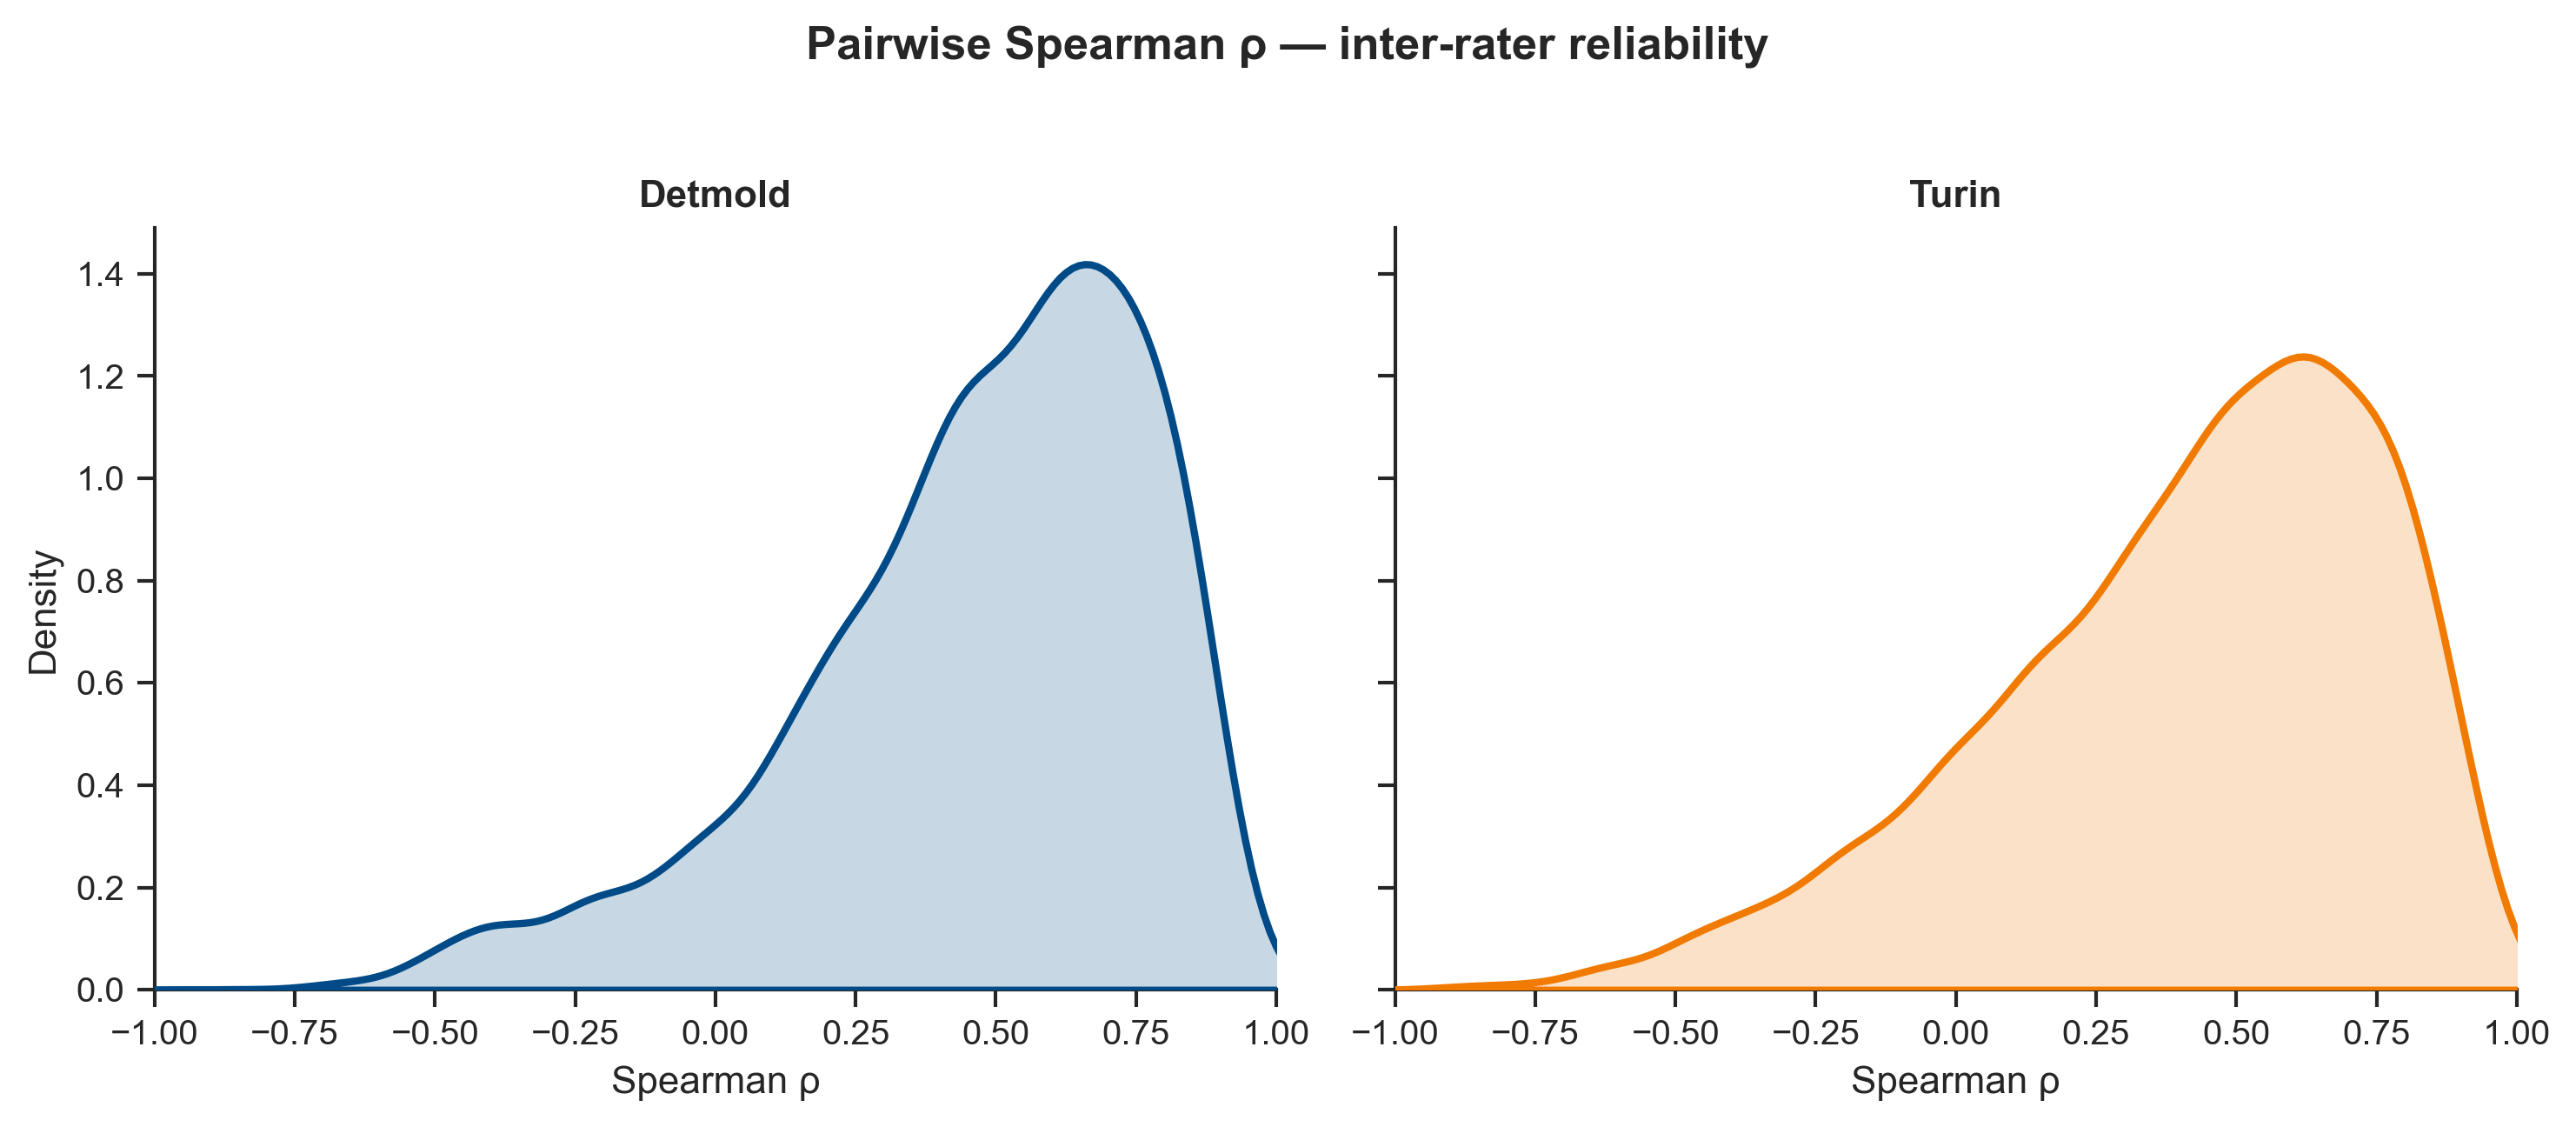

In [3]:
fig_irr = plot_inter_rater_spearman_distribution(df_survey)
save_figure(fig_irr, "fig_rq1_inter_rater_rho_dist")
display(Image(filename=FIGURES_DIR / "fig_rq1_inter_rater_rho_dist.png", width=900))


### Results and Discussion

Across 6,441 respondent pairs in Detmold, the median pairwise Spearman ρ was 0.52 (mean 0.46; interquartile range 0.29–0.70). In Turin, among 6,903 pairs, the median was 0.47 (mean 0.41; interquartile range 0.19–0.68). In both cities, the central mass of the distribution lies clearly above zero, indicating that most respondents order the same streetscapes similarly on the comfort scale, even though perfect agreement is neither expected nor observed for a perceptual outcome.

The positive medians are inconsistent with arbitrary or idiosyncratic use of the rating categories. They instead suggest that respondents are responding to shared visual cues in the images—a precondition for pooling ratings when describing city-level comfort profiles (Urban et al., 2022). Some negative pairwise correlations remain in the tails of the distribution (minimum ρ ≈ −0.86 in Detmold and −0.91 in Turin), reflecting individual disagreement on specific scenes; these do not overturn the broader pattern of within-city consensus. Comfort ratings are therefore treated as comparable within each city and aggregated for subsequent descriptive and group-based analyses. The agreement check does not claim universal consensus, but it supports the interpretability of city-scale summaries derived from pooled subjective responses.


## 2. City-level perception profiles

Photo-based streetscape surveys provide a practical way to compare thermal comfort judgments across places and populations when field measurements at every location are not feasible (Urban et al., 2022; Yang et al., 2025). Because respondents rated the same ten images in each city, city-level profiles are constructed by pooling all valid comfort scores within Detmold and Turin separately.

Comfort was recorded on a five-point ordinal scale. Although ordinal ratings are not equidistant and should be modelled cautiously in inferential work (Favero et al., 2023), reporting category frequencies and sample means remains a standard descriptive step in outdoor and streetscape comfort studies and is used here only to characterise the overall rating level and spread in each city before profile comparisons (Urban et al., 2022; Zhu et al., 2026). A summary table reports the city mean, standard deviation, number of ratings, and number of respondents with complete image sets; a companion figure shows the full rating-count distribution by city.


,city,mean,std,n_ratings,n_respondents
0,Detmold,3.000,1.084,1160,116
1,Turin,2.313,1.051,1190,119


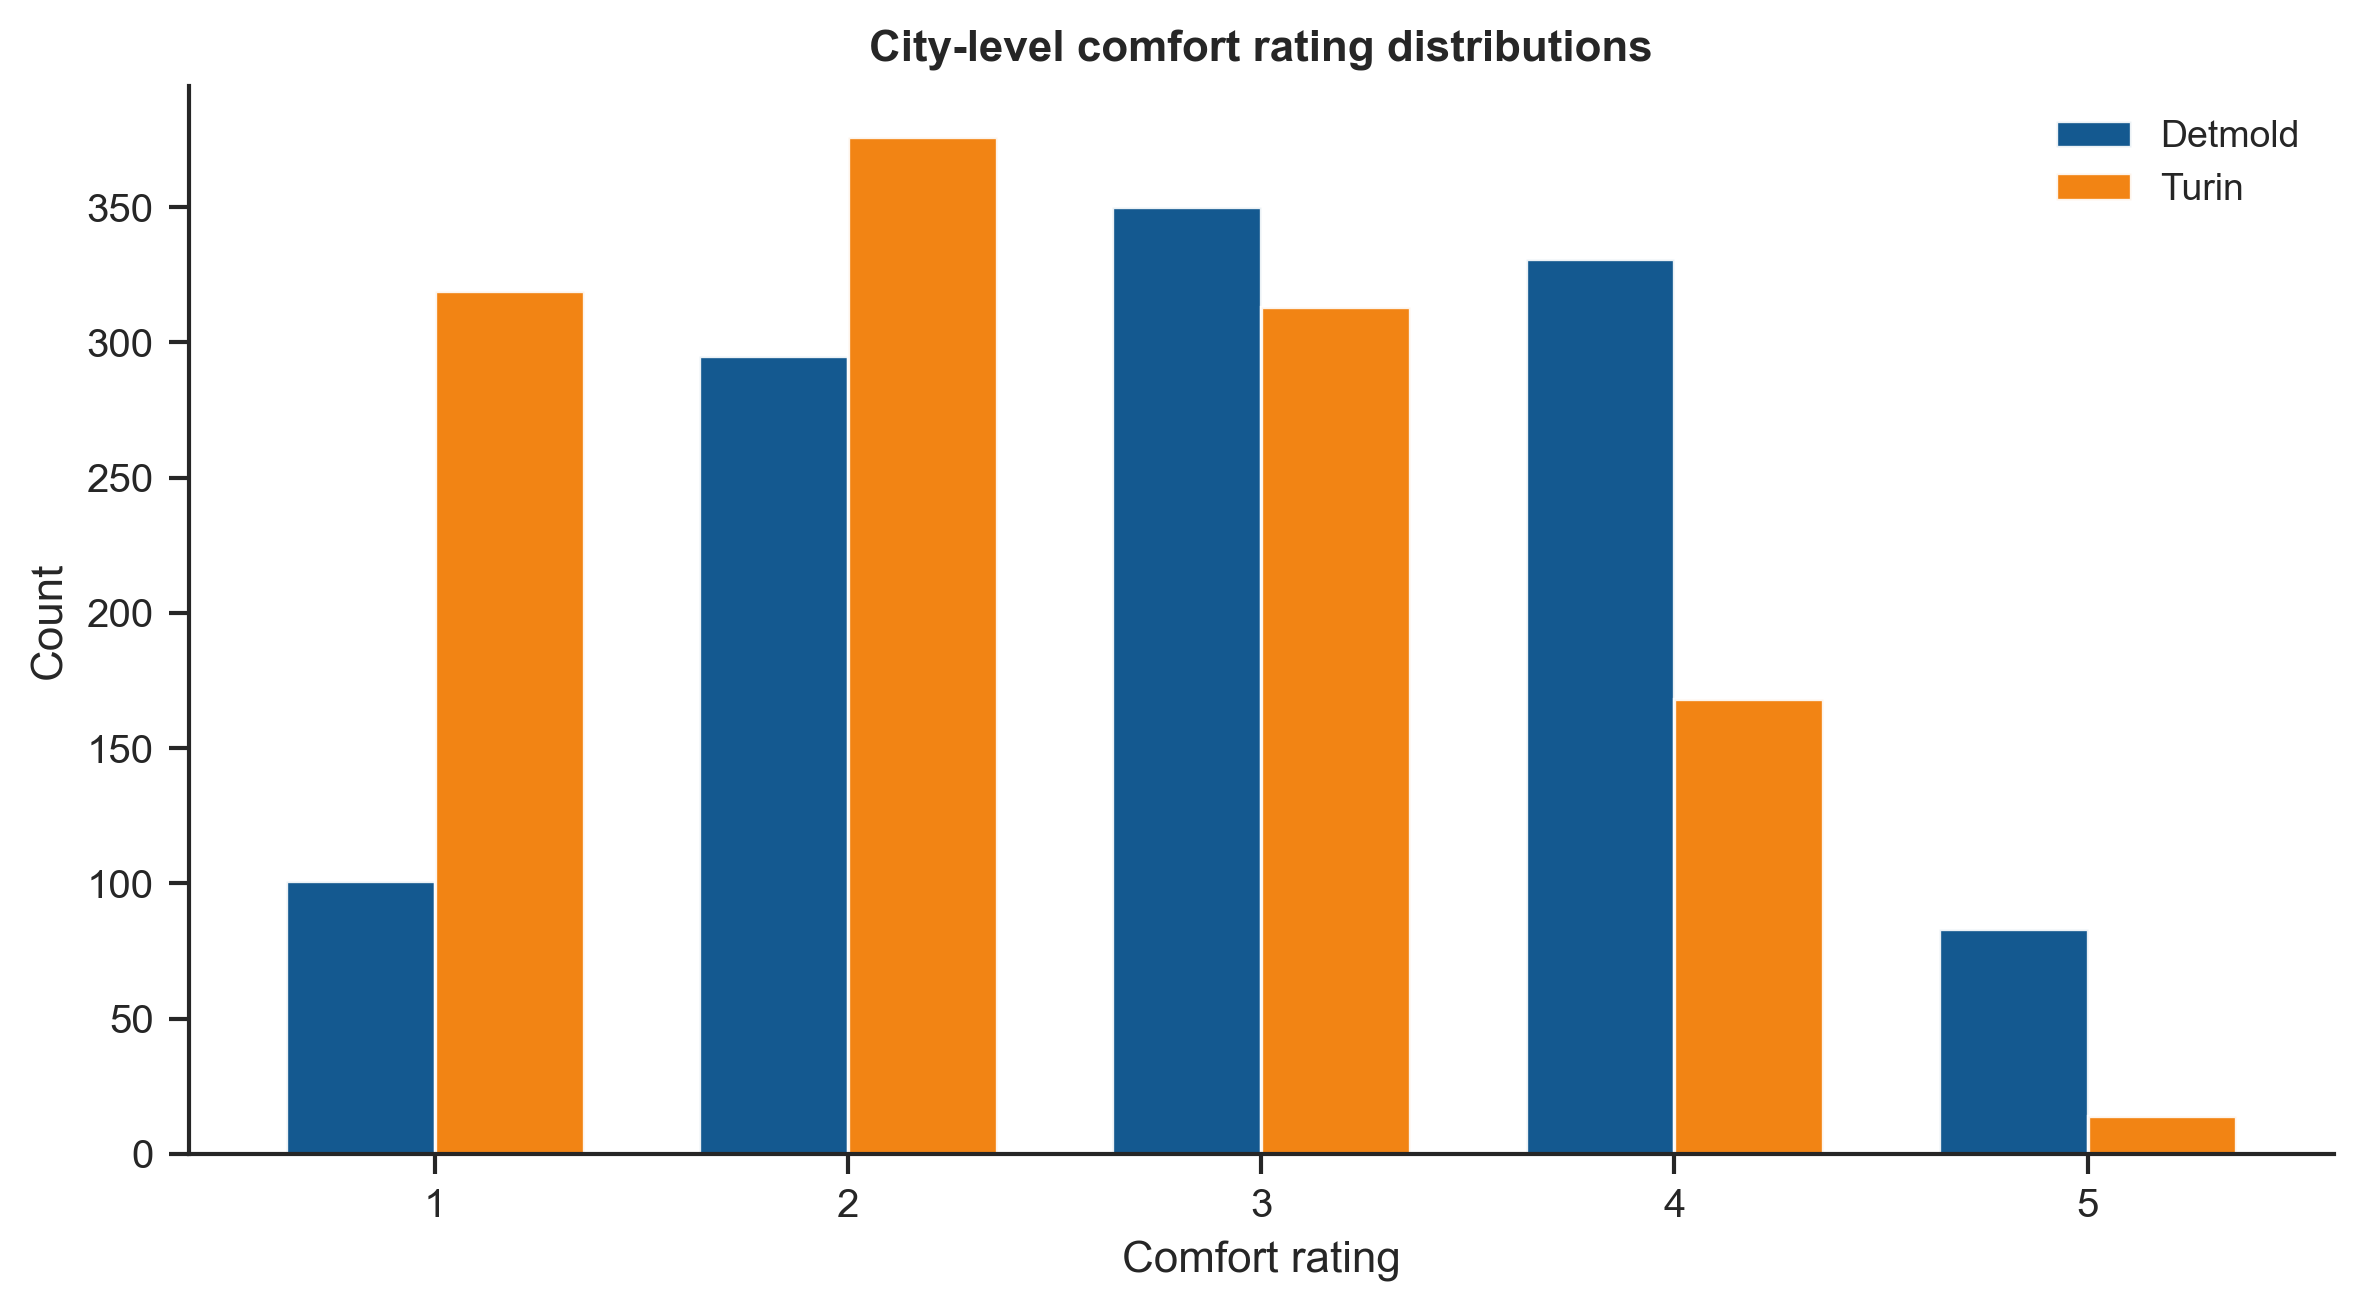

In [4]:
df_city_stats = city_level_comfort_stats(df_survey)
save_table("rq1_city_level_stats", df_city_stats)
display(df_city_stats)

fig_city = plot_city_level_distributions(df_survey)
save_figure(fig_city, "fig_rq1_city_level_distributions")
display(Image(filename=FIGURES_DIR / "fig_rq1_city_level_distributions.png", width=900))


### Results and Discussion

Across all image ratings, mean comfort was higher in Detmold (mean 3.00; SD 1.08; n = 1,160 ratings from 116 respondents) than in Turin (mean 2.31; SD 1.05; n = 1,190 ratings from 119 respondents). The Detmold distribution is shifted toward the upper half of the five-point scale, whereas Turin responses concentrate more heavily on lower categories, indicating a systematically cooler perceived comfort level in the Italian sample for the same set of streetscape images.

The city gap is descriptive rather than inferential: it summarises how the two respondent pools used the ordinal scale when judging the shared image set. That pattern is consistent with cross-city photo-based perception work, where background climate, experience, and expectations can shift reported comfort even when visual stimuli are held constant (Urban et al., 2022; Nikolopoulou & Steemers, 2003). These city-level profiles provide the reference against which respondent-group differences in the next sections are interpreted.


## 3. Comfort ratings comparison across respondent profiles

Outdoor thermal comfort is shaped not only by microclimate but also by personal and behavioural context—among them age, heat adaptation, and travel behaviour (Nikolopoulou & Steemers, 2003; Chen et al., 2022; Lenzholzer & de Vries, 2020). Recent streetscape studies likewise treat questionnaire-based respondent characteristics as relevant modifiers of visually assessed comfort (Zhu et al., 2026; Yang et al., 2025).

### Rationale for a-priori category harmonisation

Profile comparisons are based on category means that aggregate few observations per cell. When response categories are numerous and unevenly populated, some groups contain only a handful of respondents. Means computed in such sparse cells are statistically unstable—small changes in individual ratings can shift the group average markedly—and are difficult to interpret as representative of a broader population segment (Favero et al., 2023). Highly skewed category distributions also reduce the informational value of descriptive comparisons: a profile figure dominated by one or two large bars alongside several very thin bars conveys little beyond sampling imbalance rather than systematic comfort differentiation (Urban et al., 2022).

For these reasons, response categories were reviewed **before** comfort outcomes were examined, using the full survey sample documented in `survey-results.docx`. Adjacent or substantively similar options were merged where doing so (i) redistributes respondents into more balanced groups, (ii) avoids reliance on cells with very low counts, and (iii) preserves interpretable contrasts that the questionnaire design intended to capture. This **a-priori** approach limits post-hoc collapsing driven by observed mean differences, which would risk overfitting the category structure to the comfort data at hand. Comparable outdoor-comfort syntheses likewise treat socio-demographic grouping as a design decision informed by sample composition and field context, not as an iterative optimisation against the outcome (Chen et al., 2022).

Non-binary gender respondents were **excluded** from profile analyses rather than merged into another category, because the resulting cell size (n = 1 in Detmold) cannot support a meaningful group mean and would not permit defensible comparison with other gender categories.

The following harmonisation rules were applied:

- **Gender:** non-binary respondents excluded (see above).
- **Age:** 46–55, 56–65, and over 65 merged into **Over 46**; younger bands retained separately.
- **Birthplace:** in city and in region merged.
- **Education:** high school with vocational training; master's with PhD.
- **Occupation:** retired with unemployed; full-time with part-time and self-employed.
- **Daily activity:** mixed (indoors and outdoors) with outdoors.
- **Time in city:** less than 1 year with 1–3 years; more than 10 years with since birth.

All other retained questionnaire fields keep their original response categories.

### Method and interpretation

Mean comfort is measured on a five-point ordinal scale in which **higher** values indicate that respondents expect to feel **thermally more comfortable** walking through the streetscape shown, and **lower** values indicate **less comfortable** expectations (Urban et al., 2022; Zhu et al., 2026). For each preprocessing-retained variable, mean comfort is computed as the respondent-level average across all ten image ratings, then aggregated by category within each city. Detmold and Turin each contribute **fifteen** profile fields after §1.2 variation screening and §2.2 collinearity review. An overview figure presents all variables as sub-panels with Detmold and Turin shown side by side.

Each comparison table reports mean comfort by category and includes *Difference from Average Rating* as a descriptive reference column. The interpretive discussion in §3.1–§3.15 focuses on **between-category contrasts within each city**—the absolute separation between response groups on the 1–5 comfort scale (higher = more comfortable)—because this directly indicates whether a profile dimension structures comfort ratings.

For ordinal comfort data, magnitude should be weighed alongside sample size and city context. Small shifts on the order of 0.01–0.05 points are difficult to interpret as substantively meaningful (Favero et al., 2023). The following working bands are applied throughout §3.1–§3.15:

| Contrast magnitude | Interpretation |
|--------------------|----------------|
| **< 0.10** | Negligible |
| **0.10 – 0.25** | Modest |
| **≥ 0.25** | Pronounced |

The overview figure is produced first; each retained variable is then examined in turn (§3.1–§3.15) through a comparison table and a short interpretive discussion that reports both deviation from the city mean and the principal between-category contrasts.


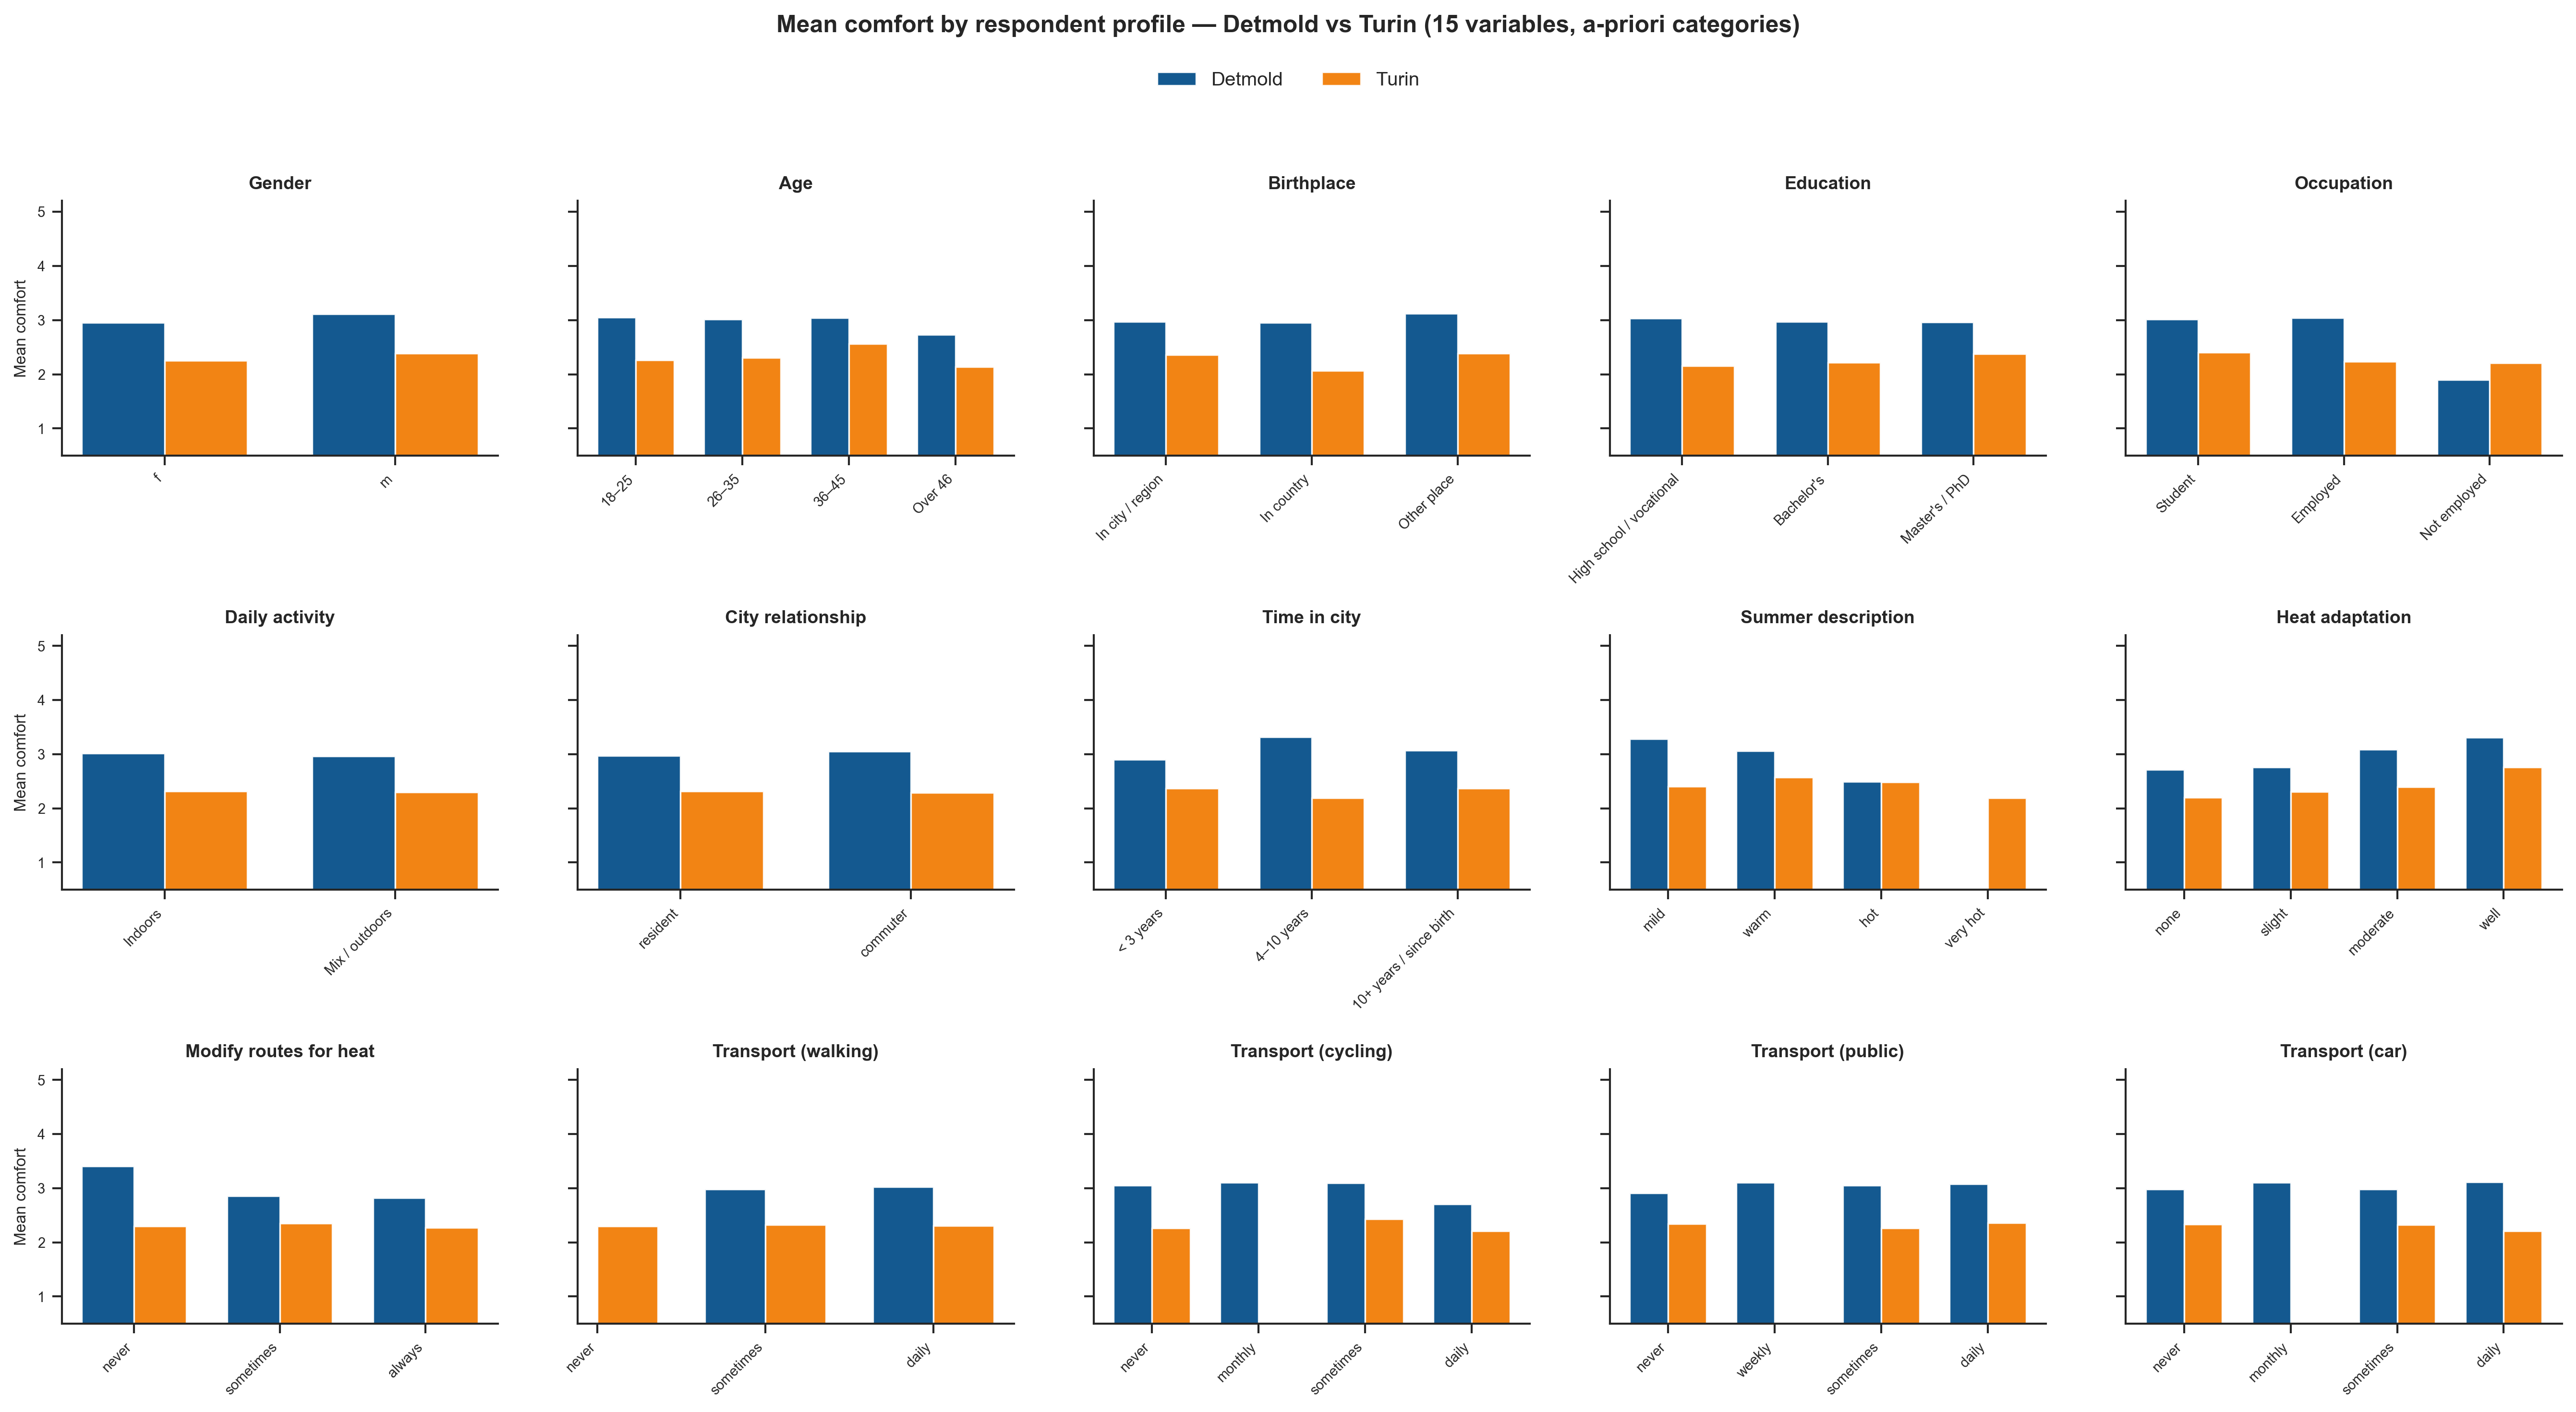

In [5]:
tables_by_variable = {
    variable: rq1_category_mean_ratings_table(df_rq1_profile, variable)
    for variable in rq1_profile_variables
}

fig = plot_category_mean_ratings_grid(
    tables_by_variable,
    city=None,
    variables=rq1_profile_variables,
    ncols=5,
    suptitle=(
        f"Mean comfort by respondent profile — Detmold vs Turin "
        f"({len(rq1_profile_variables)} variables, a-priori categories)"
    ),
)
save_figure(fig, "fig_rq1_category_means")
display(Image(filename=FIGURES_DIR / "fig_rq1_category_means.png", width=1100))


### 3.1 Gender


In [6]:
df_gender = variable_category_comparison_table(
    tables_by_variable["gender"],
    "gender",
    cities=[
        city
        for city in CITIES
        if "gender" in questionnaire_cols_by_city.get(city, [])
    ],
)
save_table("rq1_category_comparison_gender", df_gender)
display(df_gender)


,City,Category,Count,Mean Rating,Difference from Average Rating
0,Detmold,f,77,2.949,-0.053
1,Detmold,m,38,3.111,0.108
2,Turin,f,64,2.248,-0.064
3,Turin,m,55,2.387,0.075


On the five-point comfort scale, higher mean ratings indicate that respondents perceive the streetscape images as **thermally more comfortable**; lower ratings indicate **less comfortable** expectations. Between-category contrasts reveal a consistent but modest gender gap. In Detmold, male respondents assign ratings **0.16** points higher than female respondents—i.e. they perceive somewhat greater thermal comfort; in Turin, the same contrast is **0.14** points. Both exceed the **modest** threshold (≥ 0.10) yet remain well below a full scale point. Gender is associated with a small, directionally stable difference in visually assessed thermal comfort across cities, rather than a pronounced profile split.

### 3.2 Age


In [7]:
df_age = variable_category_comparison_table(
    tables_by_variable["age"],
    "age",
    cities=[
        city
        for city in CITIES
        if "age" in questionnaire_cols_by_city.get(city, [])
    ],
)
save_table("rq1_category_comparison_age", df_age)
display(df_age)


,City,Category,Count,Mean Rating,Difference from Average Rating
0,Detmold,18–25,61,3.049,0.047
1,Detmold,26–35,33,3.015,0.013
2,Detmold,36–45,8,3.038,0.035
3,Detmold,Over 46,13,2.731,-0.272
4,Turin,18–25,23,2.265,-0.047
5,Turin,26–35,70,2.303,-0.010
6,Turin,36–45,15,2.560,0.247
7,Turin,Over 46,11,2.136,-0.176


Higher mean ratings denote **greater** expected thermal comfort on the streetscapes shown; lower ratings denote **less** comfort.

In **Detmold**, younger age bands (18–25, 26–35, 36–45) differ from one another by at most **0.03** points (**negligible**) and report similarly **higher** comfort. **Over 46** respondents rate **0.28–0.32** points **lower** than each younger band (**pronounced**)—they perceive the images as substantially **less thermally comfortable**.

In **Turin**, **36–45** respondents rate **0.42** points **higher** than **Over 46** (**pronounced**) and **0.26** points **higher** than **26–35** (**pronounced**). Younger bands remain closely aligned (≤ **0.04**). The age–comfort association differs across cities: Detmold shows markedly **lower** comfort among older respondents, whereas Turin shows stronger separation between middle and older bands.

### 3.3 Birthplace


In [8]:
df_birthplace = variable_category_comparison_table(
    tables_by_variable["birthplace"],
    "birthplace",
    cities=[
        city
        for city in CITIES
        if "birthplace" in questionnaire_cols_by_city.get(city, [])
    ],
)
save_table("rq1_category_comparison_birthplace", df_birthplace)
display(df_birthplace)


,City,Category,Count,Mean Rating,Difference from Average Rating
0,Detmold,In city / region,54,2.969,-0.034
1,Detmold,In country,32,2.956,-0.046
2,Detmold,Other place,29,3.117,0.115
3,Turin,In city / region,26,2.362,0.049
4,Turin,In country,26,2.065,-0.247
5,Turin,Other place,67,2.390,0.077


Throughout, a **higher** category mean indicates **greater** perceived thermal comfort; a **lower** mean indicates **less** comfort.

In **Detmold**, pairwise contrasts are small (**0.01–0.16**). **Other place** respondents rate **0.16** points **higher** than **In country** respondents (**modest**). Birthplace does not meaningfully separate thermal comfort in this city.

In **Turin**, **In city / region** and **Other place** respondents perceive **warmer-comfort** ratings than **In country** respondents by **0.30** and **0.33** points respectively (**pronounced**). The two higher-rating groups differ by only **0.03** (**negligible**). Place of birth structures perceived thermal comfort in Turin but not in Detmold.

### 3.4 Education


In [9]:
df_education = variable_category_comparison_table(
    tables_by_variable["education"],
    "education",
    cities=[
        city
        for city in CITIES
        if "education" in questionnaire_cols_by_city.get(city, [])
    ],
)
save_table("rq1_category_comparison_education", df_education)
display(df_education)


,City,Category,Count,Mean Rating,Difference from Average Rating
0,Detmold,High school / vocational,65,3.032,0.030
1,Detmold,Bachelor's,27,2.967,-0.036
2,Detmold,Master's / PhD,23,2.961,-0.042
3,Turin,High school / vocational,9,2.156,-0.157
4,Turin,Bachelor's,34,2.215,-0.098
5,Turin,Master's / PhD,76,2.375,0.062


Mean ratings are read as perceived thermal comfort: **higher** values = **more comfortable**, **lower** values = **less comfortable**.

In **Detmold**, education categories differ by at most **0.07** (**negligible**); no group consistently perceives the streetscapes as more or less comfortable than another.

In **Turin**, **Master's / PhD** respondents rate **0.22** points **higher** than **High school / vocational** and **0.16** points **higher** than **Bachelor's** respondents (**modest** in both cases). The vocational group perceives the lowest comfort, but no contrast reaches the **pronounced** band and that cell is small (n = 9).

### 3.5 Occupation


In [10]:
df_occupation = variable_category_comparison_table(
    tables_by_variable["occupation"],
    "occupation",
    cities=[
        city
        for city in CITIES
        if "occupation" in questionnaire_cols_by_city.get(city, [])
    ],
)
save_table("rq1_category_comparison_occupation", df_occupation)
display(df_occupation)


,City,Category,Count,Mean Rating,Difference from Average Rating
0,Detmold,Student,85,3.016,0.014
1,Detmold,Employed,28,3.039,0.037
2,Detmold,Not employed,2,1.900,-1.103
3,Turin,Student,57,2.404,0.091
4,Turin,Employed,52,2.233,-0.080
5,Turin,Not employed,10,2.210,-0.103


On the comfort scale used here, **higher** means = **more thermally comfortable** judgements; **lower** means = **less comfortable** judgements.

In **Detmold**, **Student** and **Employed** respondents differ by only **0.02** (**negligible**). **Not employed** respondents rate **1.12–1.14** points **lower** than other occupation groups—i.e. they perceive markedly **less** thermal comfort—but with only **two** respondents this contrast cannot be interpreted reliably.

In **Turin**, **Student** respondents rate **0.17–0.19** points **higher** than **Employed** and **Not employed** respondents (**modest**), indicating somewhat **greater** perceived comfort. **Employed** and **Not employed** groups are virtually aligned (**0.02**, **negligible**).

### 3.6 Daily activity


In [11]:
df_daily_activity = variable_category_comparison_table(
    tables_by_variable["daily_activity"],
    "daily_activity",
    cities=[
        city
        for city in CITIES
        if "daily_activity" in questionnaire_cols_by_city.get(city, [])
    ],
)
save_table("rq1_category_comparison_daily_activity", df_daily_activity)
display(df_daily_activity)


,City,Category,Count,Mean Rating,Difference from Average Rating
0,Detmold,Indoors,91,3.013,0.011
1,Detmold,Mix / outdoors,24,2.962,-0.040
2,Turin,Indoors,87,2.320,0.007
3,Turin,Mix / outdoors,32,2.294,-0.019


Higher mean comfort ratings reflect **more favourable** thermal expectations; lower ratings reflect **less favourable** expectations. After merging mixed and outdoor activity, **Indoors** versus **Mix / outdoors** differs by **0.05** in Detmold and **0.03** in Turin—both **negligible**. Indoor and mixed/outdoor activity settings do not meaningfully separate perceived thermal comfort in either city.

### 3.7 City relationship


In [12]:
df_city_relationship = variable_category_comparison_table(
    tables_by_variable["city_relationship"],
    "city_relationship",
    cities=[
        city
        for city in CITIES
        if "city_relationship" in questionnaire_cols_by_city.get(city, [])
    ],
)
save_table("rq1_category_comparison_city_relationship", df_city_relationship)
display(df_city_relationship)


,City,Category,Count,Mean Rating,Difference from Average Rating
0,Detmold,resident,71,2.970,-0.032
1,Detmold,commuter,44,3.055,0.052
2,Turin,resident,109,2.315,0.002
3,Turin,commuter,10,2.290,-0.023


Mean rating is interpreted as perceived thermal comfort (**higher** = **more comfortable**). The resident–commuter contrast is **0.09** in Detmold and **0.03** in Turin—both **negligible**. Commuters rate comfort marginally **lower** than residents in Detmold, but the gap is too small to treat as substantively meaningful in either city.

### 3.8 Time in city


In [13]:
df_time_in_city = variable_category_comparison_table(
    tables_by_variable["time_in_city"],
    "time_in_city",
    cities=[
        city
        for city in CITIES
        if "time_in_city" in questionnaire_cols_by_city.get(city, [])
    ],
)
save_table("rq1_category_comparison_time_in_city", df_time_in_city)
display(df_time_in_city)


,City,Category,Count,Mean Rating,Difference from Average Rating
0,Detmold,< 3 years,74,2.897,-0.105
1,Detmold,4–10 years,21,3.314,0.312
2,Detmold,10+ years / since birth,20,3.065,0.062
3,Turin,< 3 years,61,2.370,0.058
4,Turin,4–10 years,38,2.189,-0.123
5,Turin,10+ years / since birth,20,2.370,0.057


**Higher** mean ratings indicate that a group perceives the streetscape images as **more thermally comfortable**; **lower** ratings indicate **less** comfort.

In **Detmold**, respondents with **4–10 years** in the city rate **0.42** points **higher** than those with **< 3 years** (**pronounced**) and **0.25** points **higher** than **10+ years / since birth** (**pronounced**)—i.e. mid-tenure residents report the **most** comfortable expectations.

In **Turin**, **< 3 years** and **10+ years / since birth** groups share the same mean (contrast **0.00**), while **4–10 years** respondents rate **0.18** points **lower** than the **< 3 years** group (**modest**)—a weaker and differently ordered pattern than in Detmold.

### 3.9 Summer climate description


In [14]:
df_summer_description = variable_category_comparison_table(
    tables_by_variable["summer_description"],
    "summer_description",
    cities=[
        city
        for city in CITIES
        if "summer_description" in questionnaire_cols_by_city.get(city, [])
    ],
)
save_table("rq1_category_comparison_summer_description", df_summer_description)
display(df_summer_description)


,City,Category,Count,Mean Rating,Difference from Average Rating
0,Detmold,mild,18,3.283,0.281
1,Detmold,warm,79,3.056,0.053
2,Detmold,hot,18,2.489,-0.514
3,Turin,mild,1,2.400,0.087
4,Turin,warm,13,2.569,0.257
5,Turin,hot,32,2.484,0.172
6,Turin,very_hot,73,2.190,-0.122


Comfort ratings increase with **more favourable** thermal expectations: **higher** means = streetscapes judged **more comfortable**, **lower** means = **less comfortable**.

In **Detmold**, respondents who describe summers as **mild** rate images **0.79** points **higher** than those who describe them as **hot**, and **warm** respondents rate **0.57** points **higher** than **hot** respondents—both **pronounced**. Those associating summers with **hot** conditions perceive the **least** thermal comfort.

In **Turin**, **warm** respondents rate **0.38** points **higher** than **very hot** and **hot** respondents **0.29** points **higher** than **very hot** (**pronounced**). The **mild** category rests on one respondent. Summer-climate labels align more sharply with perceived comfort in Detmold than in Turin.

### 3.10 Heat adaptation


In [15]:
df_heat_adaptation = variable_category_comparison_table(
    tables_by_variable["heat_adaptation"],
    "heat_adaptation",
    cities=[
        city
        for city in CITIES
        if "heat_adaptation" in questionnaire_cols_by_city.get(city, [])
    ],
)
save_table("rq1_category_comparison_heat_adaptation", df_heat_adaptation)
display(df_heat_adaptation)


,City,Category,Count,Mean Rating,Difference from Average Rating
0,Detmold,none,6,2.717,-0.286
1,Detmold,slight,37,2.762,-0.240
2,Detmold,moderate,51,3.084,0.082
3,Detmold,well,21,3.310,0.307
4,Turin,none,39,2.197,-0.115
5,Turin,slight,47,2.311,-0.002
6,Turin,moderate,28,2.396,0.084
7,Turin,well,5,2.760,0.447


**Higher** comfort ratings indicate **greater** perceived thermal comfort; **lower** ratings indicate **less** comfort.

In **Detmold**, **well** adapted respondents rate **0.55–0.59** points **higher** than **slight** or **not** adapted groups (**pronounced**), and **moderate** adaptation sits **0.32** points **above** **slight** adaptation (**pronounced**). Greater self-reported heat adaptation co-occurs with **more comfortable** streetscape ratings.

In **Turin**, contrasts involving **well** adapted respondents reach **0.36–0.56** points (**pronounced**), but that cell has only **five** respondents. Among larger groups, separation is **modest** at most. The adaptation–comfort gradient is more consistent in Detmold.

### 3.11 Modify routes for heat


In [16]:
df_modify_routes_heat = variable_category_comparison_table(
    tables_by_variable["modify_routes_heat"],
    "modify_routes_heat",
    cities=[
        city
        for city in CITIES
        if "modify_routes_heat" in questionnaire_cols_by_city.get(city, [])
    ],
)
save_table("rq1_category_comparison_modify_routes_heat", df_modify_routes_heat)
display(df_modify_routes_heat)


,City,Category,Count,Mean Rating,Difference from Average Rating
0,Detmold,never,32,3.406,0.404
1,Detmold,sometimes,69,2.852,-0.150
2,Detmold,always,14,2.821,-0.181
3,Turin,never,5,2.300,-0.013
4,Turin,sometimes,59,2.354,0.042
5,Turin,always,55,2.269,-0.044


A **higher** mean rating means respondents expect **more** thermal comfort in the scenes shown; a **lower** mean means **less** comfort.

In **Detmold**, respondents who **never** modify routes because of heat rate **0.55–0.59** points **higher** than those who **sometimes** or **always** modify routes (**pronounced**)—they perceive the streetscapes as substantially **more comfortable**. **Sometimes** and **always** modifiers differ by only **0.03** (**negligible**).

In **Turin**, all pairwise contrasts are **negligible** (maximum **0.09**). Route-modification behaviour separates perceived thermal comfort strongly in Detmold but not in Turin.

### 3.12 Transport (walking)


In [17]:
df_transport_walking = variable_category_comparison_table(
    tables_by_variable["transport_walking"],
    "transport_walking",
    cities=[
        city
        for city in CITIES
        if "transport_walking" in questionnaire_cols_by_city.get(city, [])
    ],
)
save_table("rq1_category_comparison_transport_walking", df_transport_walking)
display(df_transport_walking)


,City,Category,Count,Mean Rating,Difference from Average Rating
0,Detmold,sometimes,46,2.976,-0.027
1,Detmold,daily,69,3.020,0.018
2,Turin,never,8,2.300,-0.013
3,Turin,sometimes,53,2.323,0.010
4,Turin,daily,58,2.305,-0.007


Comfort ratings are ordinal indicators of perceived thermal comfort (**higher** = **more comfortable**). All between-category contrasts are **negligible** (maximum **0.04** in Detmold; **0.02** in Turin). Walking frequency does not differentiate how **comfortable** respondents judge the streetscape images.

### 3.13 Transport (cycling)


In [18]:
df_transport_cycling = variable_category_comparison_table(
    tables_by_variable["transport_cycling"],
    "transport_cycling",
    cities=[
        city
        for city in CITIES
        if "transport_cycling" in questionnaire_cols_by_city.get(city, [])
    ],
)
save_table("rq1_category_comparison_transport_cycling", df_transport_cycling)
display(df_transport_cycling)


,City,Category,Count,Mean Rating,Difference from Average Rating
0,Detmold,never,51,3.049,0.046
1,Detmold,monthly,1,3.100,0.097
2,Detmold,sometimes,42,3.093,0.090
3,Detmold,daily,21,2.705,-0.298
4,Turin,never,65,2.265,-0.048
5,Turin,sometimes,40,2.427,0.115
6,Turin,daily,14,2.207,-0.105


**Higher** ratings = **more** thermal comfort; **lower** ratings = **less** thermal comfort.

In **Detmold**, **daily** cyclists rate **0.34–0.39** points **lower** than **never** or **sometimes** cyclists (**pronounced**)—they perceive the images as **less comfortable**. Non-daily frequency categories differ by at most **0.05** (**negligible**).

In **Turin**, **sometimes** cyclists rate **0.22** points **higher** than **daily** cyclists (**modest**), indicating somewhat **greater** perceived comfort among occasional cyclists. The association is weaker than in Detmold.

### 3.14 Transport (public)


In [19]:
df_transport_public = variable_category_comparison_table(
    tables_by_variable["transport_public"],
    "transport_public",
    cities=[
        city
        for city in CITIES
        if "transport_public" in questionnaire_cols_by_city.get(city, [])
    ],
)
save_table("rq1_category_comparison_transport_public", df_transport_public)
display(df_transport_public)


,City,Category,Count,Mean Rating,Difference from Average Rating
0,Detmold,never,42,2.907,-0.095
1,Detmold,weekly,1,3.100,0.097
2,Detmold,sometimes,57,3.053,0.050
3,Detmold,daily,15,3.073,0.071
4,Turin,never,11,2.345,0.033
5,Turin,sometimes,53,2.258,-0.054
6,Turin,daily,55,2.358,0.046


Mean rating reflects perceived thermal comfort on a scale where **higher** values are **more comfortable**.

In **Detmold**, between-category contrasts are generally small (**0.02–0.19**); the largest is **never** versus **weekly** (**0.19**, **modest**), with **weekly** based on one respondent.

In **Turin**, the maximum gap is **0.10** (**sometimes** versus **daily**, **modest**). Public-transport frequency does not strongly separate **more** versus **less comfortable** judgements in either city.

### 3.15 Transport (car)


In [20]:
df_transport_car = variable_category_comparison_table(
    tables_by_variable["transport_car"],
    "transport_car",
    cities=[
        city
        for city in CITIES
        if "transport_car" in questionnaire_cols_by_city.get(city, [])
    ],
)
save_table("rq1_category_comparison_transport_car", df_transport_car)
display(df_transport_car)


,City,Category,Count,Mean Rating,Difference from Average Rating
0,Detmold,never,40,2.980,-0.023
1,Detmold,monthly,1,3.100,0.097
2,Detmold,sometimes,56,2.982,-0.020
3,Detmold,daily,18,3.111,0.109
4,Turin,never,81,2.330,0.017
5,Turin,sometimes,22,2.327,0.015
6,Turin,daily,16,2.206,-0.106


**Higher** mean comfort = **more thermally comfortable** expectations; **lower** mean = **less comfortable** expectations.

In **Detmold**, **daily** car users rate **0.13** points **higher** than **never** or **sometimes** users (**modest**)—a slightly **more comfortable** profile.

In **Turin**, **daily** car users rate **0.12** points **lower** than **never** or **sometimes** users (**modest**)—the opposite direction to Detmold. Overall, car-use frequency shows at most **modest** separation in how **comfortable** the streetscapes are judged.

### 3.16 Transport modes — active users (daily or sometimes)

The four transport questions (§3.12–§3.15) report mean comfort by frequency category. The table below pools respondents who use each mode **daily** or **sometimes** in summer—i.e. those who report at least occasional outdoor use of walking, cycling, public transport, or private car—and reports the mean comfort rating for each group within Detmold and Turin.


In [21]:
TRANSPORT_MODES = [
    ("transport_walking", "Walking"),
    ("transport_cycling", "Cycling"),
    ("transport_public", "Public transport"),
    ("transport_car", "Car"),
]
ACTIVE_TRANSPORT_FREQ = {"daily", "sometimes"}

transport_active_rows: list[dict[str, object]] = []
for city in CITIES:
    city_df = df_rq1_profile.loc[df_rq1_profile["questionnaire_city"] == city]
    for variable, label in TRANSPORT_MODES:
        if variable not in questionnaire_cols_by_city.get(city, []):
            continue
        active = city_df.loc[city_df[variable].isin(ACTIVE_TRANSPORT_FREQ)]
        if active.empty:
            continue
        ratings = active[cfg.POINT_COLUMNS].apply(pd.to_numeric, errors="coerce").mean(axis=1)
        transport_active_rows.append(
            {
                "City": city,
                "Transport mode": label,
                "Frequency": "daily or sometimes",
                "Count": len(active),
                "Mean Rating": round(float(ratings.mean()), 3),
            }
        )

df_transport_active_users = pd.DataFrame(transport_active_rows)
save_table("rq1_transport_active_users_mean_ratings", df_transport_active_users)
display(df_transport_active_users)


,City,Transport mode,Frequency,Count,Mean Rating
0,Detmold,Walking,daily or sometimes,115,3.003
1,Detmold,Cycling,daily or sometimes,63,2.963
2,Detmold,Public transport,daily or sometimes,72,3.057
3,Detmold,Car,daily or sometimes,74,3.014
4,Turin,Walking,daily or sometimes,111,2.314
5,Turin,Cycling,daily or sometimes,54,2.370
6,Turin,Public transport,daily or sometimes,108,2.309
7,Turin,Car,daily or sometimes,38,2.276


**Higher** mean ratings indicate **greater** perceived thermal comfort on the 1–5 scale.

In **Detmold**, mean comfort among active users is similar across modes (about **2.96–3.06**). Public-transport users show the highest mean (**3.06**); cycling users the lowest (**2.96**).

In **Turin**, active users also cluster tightly (about **2.28–2.37**). Walking and cycling users rate slightly **higher** than car users; public-transport users sit near the city-wide active-user average.

These pooled summaries smooth over the frequency contrasts examined in §3.12–§3.15 and describe the typical comfort profile of respondents who use each mode at least occasionally in summer.


### Results and Discussion

The overview figure summarises mean thermal comfort under the a-priori category scheme across all retained profile dimensions. On the five-point scale, **higher** bars indicate that a respondent group perceives the streetscape images as **more thermally comfortable**; **lower** bars indicate **less comfortable** expectations.

Most fields exhibit limited between-category separation, yet several dimensions show clearer structure in one or both cities—among them age, summer climate description, heat adaptation, route modification, and cycling frequency in Detmold. Male respondents consistently rate **0.14–0.16** points **higher** than female respondents (**modest**), i.e. they perceive somewhat **greater** thermal comfort. **Pronounced** pairwise gaps (≥ 0.25) appear where some categories judge the scenes substantially **more** or **less comfortable** than others—notably in summer description, heat adaptation, route modification, and time in city (Detmold)—while many other dimensions remain **negligible** (often 0.01–0.05).

These patterns support a magnitude-aware, descriptive reading of ordinal comfort ratings (Favero et al., 2023) and indicate that profile effects on visually assessed thermal comfort are dimension- and city-specific rather than uniform across Detmold and Turin (Urban et al., 2022; Zhu et al., 2026).

## References

Chen, L., Kántor, N., & Nikolopoulou, M. (2022). Meta-analysis of outdoor thermal comfort surveys in different European cities using the RUROS database: The role of background climate and gender. *Energy and Buildings*, *256*, 111757. https://doi.org/10.1016/j.enbuild.2021.111757

Favero, M., Luparelli, A., & Carlucci, S. (2023). Analysis of subjective thermal comfort data: A statistical point of view. *Energy and Buildings*, *279*, 112755. https://doi.org/10.1016/j.enbuild.2022.112755

Lenzholzer, S., & de Vries, S. (2020). Exploring outdoor thermal perception—A revised model. *International Journal of Biometeorology*, *64*, 293–300. https://doi.org/10.1007/s00484-019-01777-z

Nikolopoulou, M., & Steemers, K. (2003). Thermal comfort and psychological adaptation as a guide for designing urban spaces. *Energy and Buildings*, *35*(1), 95–101. https://doi.org/10.1016/S0378-7788(02)00084-1

Urban, J., Novotný, J., Pikl, M., & Zemek, F. (2022). Using Google Street View photographs to assess long-term outdoor thermal perception and thermal comfort in the urban environment during heatwaves. *Frontiers in Environmental Science*, *10*, 878341. https://doi.org/10.3389/fenvs.2022.878341

Wang, Y., Zhang, L., Zhao, L., & He, X. (2022). A field study of outdoor human thermal perception in three seasons in Shanghai, China. *Buildings*, *12*(9), 1453. https://doi.org/10.3390/buildings12091453

Yang, S., Chong, A., Liu, P., & Biljecki, F. (2025). Thermal comfort in sight: Thermal affordance and its visual assessment for sustainable streetscape design. *Building and Environment*, *271*, 112569. https://doi.org/10.1016/j.buildenv.2025.112569

Zhu, L., Samuelson, H. W., Biljecki, F., Tan, C. L., Wong, N. H., & Ang, Y. Q. (2026). Visual determinants of outdoor thermal comfort: Integrating explainable AI and perceptual assessments. *Building and Environment*, *293*, 114322. https://doi.org/10.1016/j.buildenv.2026.114322

Liu, R., Chen, Q., Du, M., Wang, R., Yixiao, H., Li, L., Cheng, Q., Han, H., Dong, X., & Wang, X.-C. (2026). Assessing the influence of sky view factor and building shadow ratio on thermal comfort in different local climate zones: Evidence from Beijing, China. *Journal of Urban Management*. https://doi.org/10.1016/j.jum.2026.03.006

Spearman, C. (1904). The proof and measurement of association between two things. *The American Journal of Psychology*, *15*(1), 72–101.
